<a href="https://colab.research.google.com/github/camilo299restrepo/Integracion-de-Datos-y-Prospectiva/blob/main/Reto4_Integraci%C3%B3n_Multidimensional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caso de Estudio: Solicitantes de Crédito**

Este caso de estudio busca optimizar la red de una Fintech mediante la consolidación de sus puntos de atención en solo cinco sucursales estratégicas. Para ello, se aplicará el algoritmo de agrupamiento K-Medoids sobre un conjunto de datos multidimensional que incluye variables demográficas, ingresos y detalles crediticios de los solicitantes.

El objetivo final es identificar el perfil y la procedencia de los clientes para determinar la viabilidad de las nuevas sedes, evaluando además los porcentajes de preaprobación de créditos. Los hallazgos se visualizarán mediante gráficos de araña y se desplegarán en una plataforma de GitHub como herramienta de apoyo para la toma de decisiones corporativas.

**0. Cargamos datos y archivos**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
nxl = '/content/drive/MyDrive/Integración de datos y prospectiva/4. SolicitantesCrédito(USD)_Municipios.xlsx'
xls = pd.ExcelFile(nxl)
print("Hojas disponibles:", xls.sheet_names)

Hojas disponibles: ['Base Datos Municipios']


**1. Integración de todas las hojas en un solo DataFrame**

In [4]:
XDB = pd.DataFrame()

for sheet in xls.sheet_names:
    print(sheet)
    df = pd.read_excel(xls, sheet_name=sheet)
    XDB = pd.concat([XDB, df], ignore_index=True)

Base Datos Municipios


**2. Ofuscación de los datos**

In [5]:
XDB = XDB.sample(frac=1, random_state=42).reset_index(drop=True)
XDB = XDB.dropna()

print("\nShape final:", XDB.shape)
print("Nulos restantes:", XDB.isnull().sum().sum())


Shape final: (5842, 38)
Nulos restantes: 0


**3. Se crean las semillas de integración**

In [6]:
cols_num = ['Edad', 'Hijos', 'Perscargo', 'Estrato', 'Ingresos',
            'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)']

# Semillas: primeros 5 registros (solo variables numéricas)
XC = np.array(XDB[cols_num].iloc[0:5])  # Centroides iniciales
XD = np.array(XDB[cols_num])             # Todos los datos

print('Shape XC (semillas):', XC.shape)
print('Shape XD (todos los datos):', XD.shape)

Shape XC (semillas): (5, 9)
Shape XD (todos los datos): (5842, 9)


**3. Algoritmo K-Medoids**

In [7]:
nc = np.zeros((len(XD), 1))

# Integración K-Medoids
for k in range(len(XD)):
    Xind = XD[k, ]
    m1 = np.sum(((XC[:, ] - Xind) / XC[:, ]) ** 2, axis=1)
    nc[k] = np.argmin(m1)
    cluster = int(np.argmin(m1))
    XC[cluster, ] = (XC[cluster, ] + Xind) / 2

# Tabla de centroides finales
dfxc = pd.DataFrame(XC, columns=cols_num)
dfxc.index = ['Sucursal 0','Sucursal 1','Sucursal 2','Sucursal 3','Sucursal 4']

# Conteo por sucursal
ND = []
for j in range(5):
    filasd = np.where(nc[:, ] == j)[0]
    nd = len(filasd)
    n_apr = len(np.where(XDB.iloc[filasd, XDB.columns.get_loc('PreApr')] == 1)[0])
    n_neg = len(np.where(XDB.iloc[filasd, XDB.columns.get_loc('PreApr')] == 0)[0])
    pct_apr = round(n_apr / nd * 100, 1)
    pct_neg = round(n_neg / nd * 100, 1)
    print(f'Sucursal {j}: {nd} clientes | PreAprobados: {n_apr} ({pct_apr}%) | PreNegados: {n_neg} ({pct_neg}%)')
    ND.append(nd)

dfxc['N_Clientes'] = ND

Sucursal 0: 23 clientes | PreAprobados: 0 (0.0%) | PreNegados: 23 (100.0%)
Sucursal 1: 2268 clientes | PreAprobados: 1128 (49.7%) | PreNegados: 1140 (50.3%)
Sucursal 2: 3377 clientes | PreAprobados: 1713 (50.7%) | PreNegados: 1664 (49.3%)
Sucursal 3: 55 clientes | PreAprobados: 2 (3.6%) | PreNegados: 53 (96.4%)
Sucursal 4: 119 clientes | PreAprobados: 40 (33.6%) | PreNegados: 79 (66.4%)


/tmp/ipykernel_6591/1747745749.py:6: RuntimeWarning: divide by zero encountered in divide
  m1 = np.sum(((XC[:, ] - Xind) / XC[:, ]) ** 2, axis=1)
/tmp/ipykernel_6591/1747745749.py:6: RuntimeWarning: invalid value encountered in divide
  m1 = np.sum(((XC[:, ] - Xind) / XC[:, ]) ** 2, axis=1)


**4. Municipios por Sucursal y Gráficos Araña**

In [8]:
XDB['Sucursal'] = nc.astype(int)

for j in range(5):
    filasd = np.where(nc[:, ] == j)[0]
    munis = XDB.iloc[filasd]['Municipio'].value_counts()
    print(f'\nSucursal {j} ({len(filasd)} clientes):')
    print(munis)


Sucursal 0 (23 clientes):
Municipio
Caldas    21
Itagüí     2
Name: count, dtype: int64

Sucursal 1 (2268 clientes):
Municipio
Caldas      716
Sabaneta    688
Bello       411
Itagüí      243
Medellín    184
Envigado     26
Name: count, dtype: int64

Sucursal 2 (3377 clientes):
Municipio
Sabaneta    1092
Caldas      1038
Bello        621
Itagüí       320
Medellín     256
Envigado      50
Name: count, dtype: int64

Sucursal 3 (55 clientes):
Municipio
Caldas      48
Itagüí       4
Sabaneta     3
Name: count, dtype: int64

Sucursal 4 (119 clientes):
Municipio
Caldas      55
Sabaneta    21
Itagüí      19
Bello       15
Medellín     8
Envigado     1
Name: count, dtype: int64


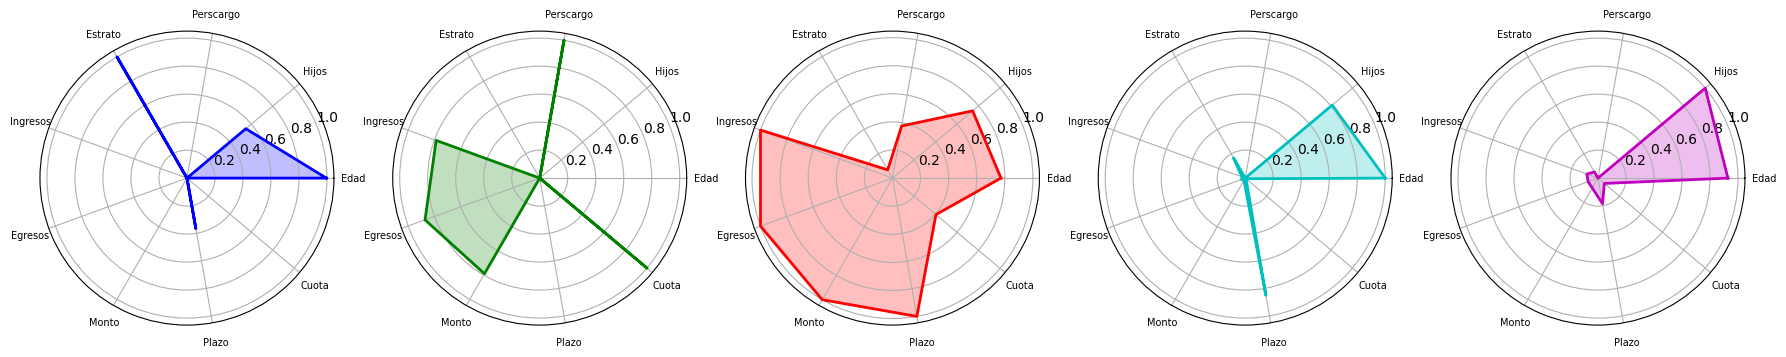

In [11]:
dfxc_norm = (dfxc - dfxc.min()) / (dfxc.max() - dfxc.min())  # normalizar 0-1

categorias = cols_num
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

colores = ['b', 'g', 'r', 'c', 'm'] # Define a list of colors

fig, axes = plt.subplots(1, 5, figsize=(22, 5), subplot_kw=dict(polar=True))

for i, ax in enumerate(axes):
    valores = dfxc_norm[categorias].iloc[i].values.flatten().tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, color=colores[i], linewidth=2)
    ax.fill(angulos, valores, color=colores[i], alpha=0.25)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(['Edad','Hijos','Perscargo','Estrato','Ingresos',
                        'Egresos','Monto','Plazo','Cuota'], size=7)